<a href="https://colab.research.google.com/github/mahidi07/badminton-pose-analysis/blob/main/02_bounding_box_crop_and_keypoint_normalisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02 - Bounding Box Crop and Keypoint Normalisation
**Project:** Automated Pose-Based Analysis of Badminton Player Movements Using Deep Learning  
**Student:** Mahidi Ilangarathna (14486346)  
**Supervisor:** A/Prof. Nabin Sharma, UTS  

---

### What this notebook does and why

Notebook 01 extracted keypoints from the full 1280x720 frame. This works but has two problems.

First, when a player is a small figure in a wide court shot, YOLOv8 has less visual detail to work with and keypoint localisation suffers, particularly for the wrists and elbows which are small and fast-moving.

Second, the raw x and y coordinates from full-frame extraction are position-dependent. A smash played from the left side of the court produces different absolute coordinates than the same smash played from the right side. The model should be learning the shape of the movement, not where on the court it happened.

This notebook replaces the Notebook 01 extraction approach with a better pipeline:

1. Detect the target player and get their bounding box
2. Expand the box slightly to avoid clipping arms and racket
3. Crop the frame to that box
4. Run YOLOv8-Pose on the cropped region only
5. Normalise keypoint coordinates to the crop dimensions so they are in 0 to 1 range
6. Save the improved .npy arrays, overwriting the Notebook 01 versions
7. Compare confidence scores before and after to quantify the improvement

The output format is identical to Notebook 01: one (30, 17, 3) array per clip. Only the quality improves.

---
## Section 1 - Setup

In [1]:
import torch

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Go to Runtime > Change runtime type and select T4 GPU.")

GPU: Tesla T4


In [2]:
!pip install ultralytics opencv-python-headless -q
print("Libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.8 MB/s eta 0:00:00
Libraries installed.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import os
from pathlib import Path
from ultralytics import YOLO

print("Imports OK")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports OK


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
BASE          = '/content/drive/MyDrive/14486346_Honours'
RAW_CLIPS_DIR = os.path.join(BASE, 'data/raw_clips')
KEYPOINTS_DIR = os.path.join(BASE, 'data/keypoints')

os.makedirs(os.path.join(BASE, 'outputs'), exist_ok=True)

TARGET_FRAMES  = 30
NUM_KEYPOINTS  = 17
CONF_THRESHOLD = 0.3
CLIPS_PER_CLASS = 10
RANDOM_SEED    = 42

# How much to expand the bounding box before cropping.
# 0.15 means 15% padding on each side. Prevents arms and racket being clipped.
BBOX_PADDING = 0.15

SKELETON_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]

KEYPOINT_NAMES = [
    'nose','left_eye','right_eye','left_ear','right_ear',
    'left_shoulder','right_shoulder','left_elbow','right_elbow',
    'left_wrist','right_wrist','left_hip','right_hip',
    'left_knee','right_knee','left_ankle','right_ankle'
]

print("Config set.")
print("Bounding box padding:", BBOX_PADDING)

Config set.
Bounding box padding: 0.15


---
## Section 2 - Load Model and Rebuild Sample List

In [6]:
pose_model = YOLO('yolov8n-pose.pt')
print("YOLOv8n-Pose loaded.")

YOLOv8n-Pose loaded.


In [7]:
# Rebuild the same sample used in Notebook 01.
# The seed is fixed so this produces the exact same clip list.

random.seed(RANDOM_SEED)

all_classes = sorted([
    d for d in os.listdir(RAW_CLIPS_DIR)
    if os.path.isdir(os.path.join(RAW_CLIPS_DIR, d))
])

sampled_clips = []
for class_name in all_classes:
    class_path = os.path.join(RAW_CLIPS_DIR, class_name)
    all_clips  = [f for f in os.listdir(class_path) if f.endswith('.mp4')]
    chosen     = random.sample(all_clips, min(CLIPS_PER_CLASS, len(all_clips)))
    for clip_file in chosen:
        sampled_clips.append((class_name, os.path.join(class_path, clip_file)))

print(f"Sample rebuilt: {len(sampled_clips)} clips across {len(all_classes)} classes.")

Sample rebuilt: 180 clips across 18 classes.


---
## Section 3 - Helper Functions

The key addition here is `get_player_crop`. It detects the largest person in the frame, expands the bounding box by `BBOX_PADDING` on all sides, clamps it to the frame boundary, and returns both the cropped image and the box coordinates. Those coordinates are then used to convert the keypoints back into normalised local space.

In [8]:
def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    return frames


def standardise_frames(frames, target=TARGET_FRAMES):
    n = len(frames)
    if n == target:
        return frames
    elif n < target:
        return frames + [frames[-1]] * (target - n)
    else:
        indices = np.linspace(0, n - 1, target, dtype=int)
        return [frames[i] for i in indices]


def get_player_crop(frame, result, padding=BBOX_PADDING):
    """
    Detects the largest person bounding box in a frame, expands it by
    `padding` on each side, and returns the cropped image along with
    the crop coordinates (x1, y1, x2, y2) in pixel space.

    Returns (crop, x1, y1, x2, y2) or (None, ...) if no detection.

    The padding prevents the racket arm and footwork from being cut off
    at the edge of a tight bounding box.
    """
    if result.boxes is None or len(result.boxes) == 0:
        return None, 0, 0, 0, 0

    H, W = frame.shape[:2]
    best_area = 0
    best_box  = None

    for box in result.boxes:
        if float(box.conf[0]) < CONF_THRESHOLD:
            continue
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        area = (x2 - x1) * (y2 - y1)
        if area > best_area:
            best_area = area
            best_box  = (x1, y1, x2, y2)

    if best_box is None:
        return None, 0, 0, 0, 0

    x1, y1, x2, y2 = best_box
    bw = x2 - x1
    bh = y2 - y1

    # Expand by padding fraction
    x1 = max(0, int(x1 - padding * bw))
    y1 = max(0, int(y1 - padding * bh))
    x2 = min(W, int(x2 + padding * bw))
    y2 = min(H, int(y2 + padding * bh))

    crop = frame[y1:y2, x1:x2]
    return crop, x1, y1, x2, y2


def extract_keypoints_cropped(video_path, model):
    """
    Improved extraction pipeline using bounding box crops.

    For each frame:
      1. Run a first-pass detection on the full frame to locate the player
      2. Crop to the padded bounding box
      3. Run pose estimation on the crop
      4. Normalise keypoint x, y coordinates to the crop dimensions (0 to 1 range)
      5. Store confidence as-is

    Normalising to the crop means the model learns movement shape and
    joint angles rather than absolute screen position.

    Returns:
        kp_array     : (TARGET_FRAMES, 17, 3) float32
        n_missing    : frames with no player detected
        original_len : frame count before standardisation
        crop_sizes   : list of (width, height) per frame, for diagnostics
    """
    frames = extract_frames(video_path)
    if not frames:
        return None, TARGET_FRAMES, 0, []

    original_len = len(frames)
    frames       = standardise_frames(frames)
    kp_array     = np.zeros((TARGET_FRAMES, NUM_KEYPOINTS, 3), dtype=np.float32)
    n_missing    = 0
    crop_sizes   = []

    # First pass: full frame detection to get bounding boxes
    first_pass = model(frames, verbose=False)

    for t, (frame, result) in enumerate(zip(frames, first_pass)):
        crop, cx1, cy1, cx2, cy2 = get_player_crop(frame, result)

        if crop is None or crop.size == 0:
            n_missing += 1
            crop_sizes.append((0, 0))
            continue

        crop_h, crop_w = crop.shape[:2]
        crop_sizes.append((crop_w, crop_h))

        # Second pass: pose estimation on the crop only
        crop_result = model(crop, verbose=False)[0]

        if crop_result.keypoints is None or len(crop_result.keypoints.data) == 0:
            n_missing += 1
            continue

        # Take the largest detection within the crop
        kps_raw = crop_result.keypoints.data[0].cpu().numpy()  # (17, 3)

        # Normalise x and y to crop dimensions so coordinates are in 0-1 range
        kps_normalised = kps_raw.copy()
        kps_normalised[:, 0] = kps_raw[:, 0] / crop_w   # x
        kps_normalised[:, 1] = kps_raw[:, 1] / crop_h   # y
        # confidence (column 2) is kept as-is

        kp_array[t] = kps_normalised

    return kp_array, n_missing, original_len, crop_sizes


print("Helper functions defined.")

Helper functions defined.


---
## Section 4 - Visual Check Before Processing

Run this on a few clips before committing to the full extraction. It shows the full frame, the padded bounding box, and the cropped region side by side so you can confirm the crop is sensible.

Wrist confidence on crop (L, R): [0.931, 0.471]


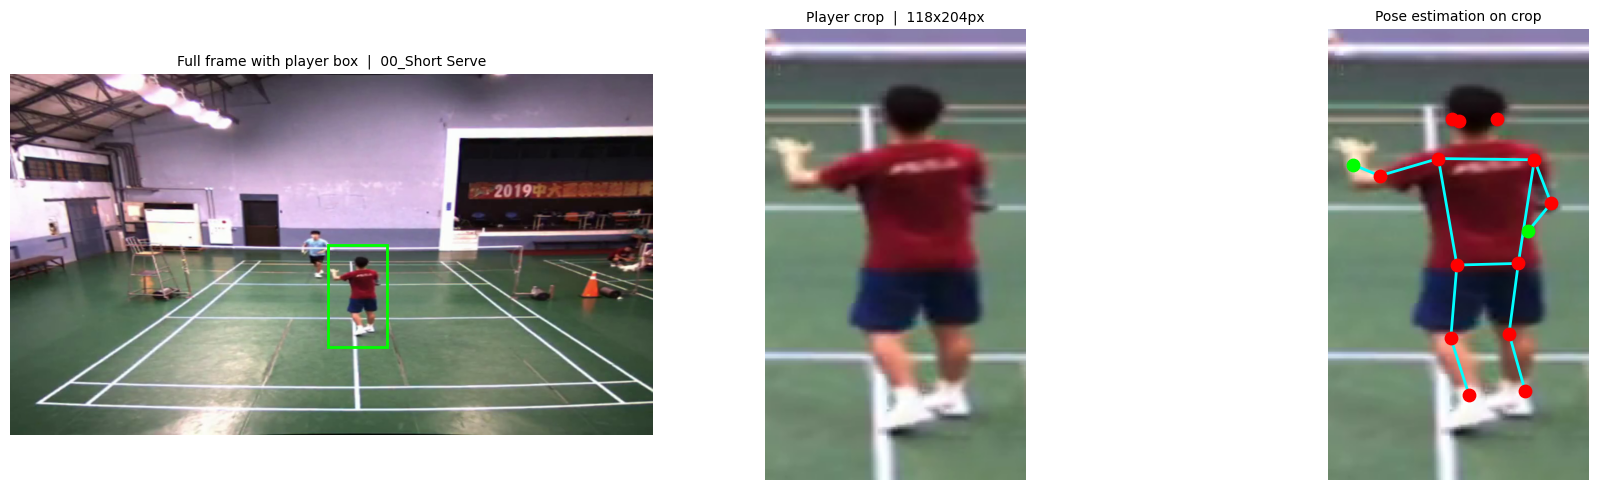

Saved to: /content/drive/MyDrive/14486346_Honours/outputs/bbox_crop_preview.png


In [9]:
# Change these to inspect any class and clip
PREVIEW_CLASS = all_classes[0]    # e.g. '00_Short_Serve'
PREVIEW_CLIP_IDX  = 0
PREVIEW_FRAME_IDX = 15

preview_clips = [(cls, p) for cls, p in sampled_clips if cls == PREVIEW_CLASS]
_, preview_path = preview_clips[PREVIEW_CLIP_IDX]

frames = extract_frames(preview_path)
frames = standardise_frames(frames)
frame  = frames[PREVIEW_FRAME_IDX].copy()

# First pass on full frame
result_full = pose_model(frame, verbose=False)[0]
crop, cx1, cy1, cx2, cy2 = get_player_crop(frame, result_full)

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

if crop is not None:
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    # Run pose on the crop
    result_crop = pose_model(crop, verbose=False)[0]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1: full frame with bounding box drawn
    axes[0].imshow(frame_rgb)
    rect = patches.Rectangle(
        (cx1, cy1), cx2 - cx1, cy2 - cy1,
        linewidth=2, edgecolor='lime', facecolor='none'
    )
    axes[0].add_patch(rect)
    axes[0].set_title(f'Full frame with player box  |  {PREVIEW_CLASS}', fontsize=10)
    axes[0].axis('off')

    # Panel 2: crop only
    axes[1].imshow(crop_rgb)
    axes[1].set_title(f'Player crop  |  {crop_rgb.shape[1]}x{crop_rgb.shape[0]}px', fontsize=10)
    axes[1].axis('off')

    # Panel 3: skeleton overlay on crop
    axes[2].imshow(crop_rgb)
    axes[2].set_title('Pose estimation on crop', fontsize=10)
    axes[2].axis('off')

    if result_crop.keypoints is not None and len(result_crop.keypoints.data) > 0:
        kps = result_crop.keypoints.data[0].cpu().numpy()
        for (j1, j2) in SKELETON_EDGES:
            x1k, y1k, c1 = kps[j1]
            x2k, y2k, c2 = kps[j2]
            if c1 > 0.3 and c2 > 0.3:
                axes[2].plot([x1k, x2k], [y1k, y2k], 'cyan', linewidth=2)
        for j, (x, y, conf) in enumerate(kps):
            if conf > 0.3:
                color = 'lime' if j in [9, 10] else 'red'
                axes[2].scatter(x, y, c=color, s=80, zorder=5)

        wrist_confs = [round(float(kps[j, 2]), 3) for j in [9, 10]]
        print("Wrist confidence on crop (L, R):", wrist_confs)
    else:
        print("No keypoints detected on crop.")

    plt.tight_layout()
    out = os.path.join(BASE, 'outputs/bbox_crop_preview.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to:", out)
else:
    print("No player detected. Try a different PREVIEW_CLASS or PREVIEW_FRAME_IDX.")

---
## Section 5 - Run Improved Extraction on Full Sample

This overwrites the Notebook 01 .npy files with the improved crop-based versions. The array shape stays the same, only the keypoint quality and coordinate space change.

In [10]:
extraction_log = []
total = len(sampled_clips)

for i, (class_name, clip_path) in enumerate(sampled_clips):
    clip_name = Path(clip_path).stem
    out_dir   = os.path.join(KEYPOINTS_DIR, class_name)
    os.makedirs(out_dir, exist_ok=True)
    out_path  = os.path.join(out_dir, f"{clip_name}.npy")

    print(f"[{i+1}/{total}] {class_name}/{clip_name} ...", end=' ', flush=True)

    kp_array, n_missing, orig_len, crop_sizes = extract_keypoints_cropped(clip_path, pose_model)

    if kp_array is None:
        print("FAILED")
        extraction_log.append({
            'clip': clip_name, 'class': class_name,
            'status': 'FAILED', 'orig_frames': 0,
            'missing_frames': TARGET_FRAMES, 'avg_crop_w': 0, 'avg_crop_h': 0
        })
        continue

    np.save(out_path, kp_array)

    valid_crops = [(w, h) for w, h in crop_sizes if w > 0]
    avg_w = int(np.mean([c[0] for c in valid_crops])) if valid_crops else 0
    avg_h = int(np.mean([c[1] for c in valid_crops])) if valid_crops else 0

    status = "OK" if n_missing == 0 else f"PARTIAL ({n_missing}/{TARGET_FRAMES} missing)"
    print(f"{status}  |  orig: {orig_len}f  |  avg crop: {avg_w}x{avg_h}px")

    extraction_log.append({
        'clip': clip_name, 'class': class_name,
        'status': 'OK' if n_missing == 0 else 'PARTIAL',
        'orig_frames': orig_len, 'missing_frames': n_missing,
        'avg_crop_w': avg_w, 'avg_crop_h': avg_h
    })

print("\nExtraction complete.")

[1/180] 00_Short Serve/2022-09-07_17-56-47_dataset_set1_029_002511_002542_A_00 ... OK  |  orig: 31f  |  avg crop: 129x208px
[2/180] 00_Short Serve/2022-08-30_18-38-37_dataset_set1_056_005859_005884_B_00 ... OK  |  orig: 25f  |  avg crop: 131x232px
[3/180] 00_Short Serve/2022-08-30_18-10-55_dataset_set1_111_010276_010301_B_00 ... OK  |  orig: 25f  |  avg crop: 119x227px
[4/180] 00_Short Serve/2022-09-07_19-24-02_dataset_set1_003_000480_000514_A_00 ... OK  |  orig: 34f  |  avg crop: 151x194px
[5/180] 00_Short Serve/2022-08-31_18-59-49_dataset_set1_015_001320_001343_A_00 ... OK  |  orig: 23f  |  avg crop: 138x223px
[6/180] 00_Short Serve/2022-08-31_18-50-39_dataset_set1_015_002323_002347_B_00 ... OK  |  orig: 24f  |  avg crop: 122x232px
[7/180] 00_Short Serve/2022-08-31_18-36-59_dataset_set1_085_005993_006016_A_00 ... OK  |  orig: 23f  |  avg crop: 134x209px
[8/180] 00_Short Serve/2022-08-30_19-19-43_dataset_set1_067_005761_005783_B_00 ... OK  |  orig: 22f  |  avg crop: 127x212px
[9/180] 

In [11]:
if extraction_log:
    ok      = sum(1 for s in extraction_log if s['status'] == 'OK')
    partial = sum(1 for s in extraction_log if s['status'] == 'PARTIAL')
    failed  = sum(1 for s in extraction_log if s['status'] == 'FAILED')
    valid   = [s for s in extraction_log if s['status'] != 'FAILED']
    avg_missing = np.mean([s['missing_frames'] for s in valid]) if valid else 0
    avg_crop_w  = np.mean([s['avg_crop_w'] for s in valid if s['avg_crop_w'] > 0]) if valid else 0
    avg_crop_h  = np.mean([s['avg_crop_h'] for s in valid if s['avg_crop_h'] > 0]) if valid else 0

    print("EXTRACTION SUMMARY (crop-based)")
    print("-" * 45)
    print(f"  Total clips      : {len(extraction_log)}")
    print(f"  Clean            : {ok}")
    print(f"  Partial          : {partial}")
    print(f"  Failed           : {failed}")
    print(f"  Avg missing      : {avg_missing:.1f} / {TARGET_FRAMES} frames")
    print(f"  Avg crop size    : {int(avg_crop_w)}x{int(avg_crop_h)} px")
    print()

    print(f"{'Class':<30} {'OK':>4} {'Partial':>8} {'Avg crop':>10}")
    print("-" * 55)
    for cls in all_classes:
        cls_logs = [s for s in extraction_log if s['class'] == cls]
        if not cls_logs:
            continue
        c_ok  = sum(1 for s in cls_logs if s['status'] == 'OK')
        c_par = sum(1 for s in cls_logs if s['status'] == 'PARTIAL')
        crops = [s['avg_crop_w'] for s in cls_logs if s['avg_crop_w'] > 0]
        avg_w_cls = int(np.mean(crops)) if crops else 0
        print(f"  {cls:<28} {c_ok:>4} {c_par:>8} {avg_w_cls:>8}px wide")

EXTRACTION SUMMARY (crop-based)
---------------------------------------------
  Total clips      : 180
  Clean            : 173
  Partial          : 7
  Failed           : 0
  Avg missing      : 0.2 / 30 frames
  Avg crop size    : 167x237 px

Class                            OK  Partial   Avg crop
-------------------------------------------------------
  00_Short Serve                 10        0      129px wide
  01_Cross Court Flight           8        2      163px wide
  02_Lift                         9        1      160px wide
  03_Tap Smash                   10        0      181px wide
  04_Block                       10        0      176px wide
  05_Drop Shot                    9        1      148px wide
  06_Push Shot                    9        1      171px wide
  07_Transitional Slice          10        0      178px wide
  08_Cut                         10        0      177px wide
  09_Rush Shot                    9        1      106px wide
  10_Defensive Clear             1

---
## Section 6 - Confidence Comparison: Full Frame vs Crop

This section runs the old full-frame approach on a small set of clips and compares the resulting keypoint confidence against the crop-based approach. It gives a concrete number for how much the cropping improves detection quality.

In [12]:
# Compare confidence on 5 clips (one per class from the first 5 classes)
COMPARE_CLIPS = [(cls, p) for cls, p in sampled_clips if cls in all_classes[:5]][:5]

full_frame_confs = []
crop_confs       = []

for class_name, clip_path in COMPARE_CLIPS:
    frames = standardise_frames(extract_frames(clip_path))
    if not frames:
        continue

    # Full frame approach
    ff_results = pose_model(frames, verbose=False)
    ff_clip_conf = []
    for result in ff_results:
        if result.keypoints is not None and len(result.keypoints.data) > 0:
            ff_clip_conf.append(float(result.keypoints.data[0, :, 2].mean().cpu()))
    if ff_clip_conf:
        full_frame_confs.append(np.mean(ff_clip_conf))

    # Crop approach
    kp_arr, _, _, _ = extract_keypoints_cropped(clip_path, pose_model)
    if kp_arr is not None:
        nonzero = kp_arr[kp_arr[:, :, 2] > 0]
        if len(nonzero):
            crop_confs.append(float(nonzero[:, 2].mean()))

print("Mean keypoint confidence comparison (averaged across sample clips):")
print(f"  Full frame approach : {np.mean(full_frame_confs):.4f}")
print(f"  Crop-based approach : {np.mean(crop_confs):.4f}")
if np.mean(full_frame_confs) > 0:
    improvement = (np.mean(crop_confs) - np.mean(full_frame_confs)) / np.mean(full_frame_confs) * 100
    print(f"  Relative improvement: {improvement:+.1f}%")

Mean keypoint confidence comparison (averaged across sample clips):
  Full frame approach : 0.7465
  Crop-based approach : 0.7607
  Relative improvement: +1.9%


---
## Section 7 - Per-Joint Confidence Chart (Post-Crop)

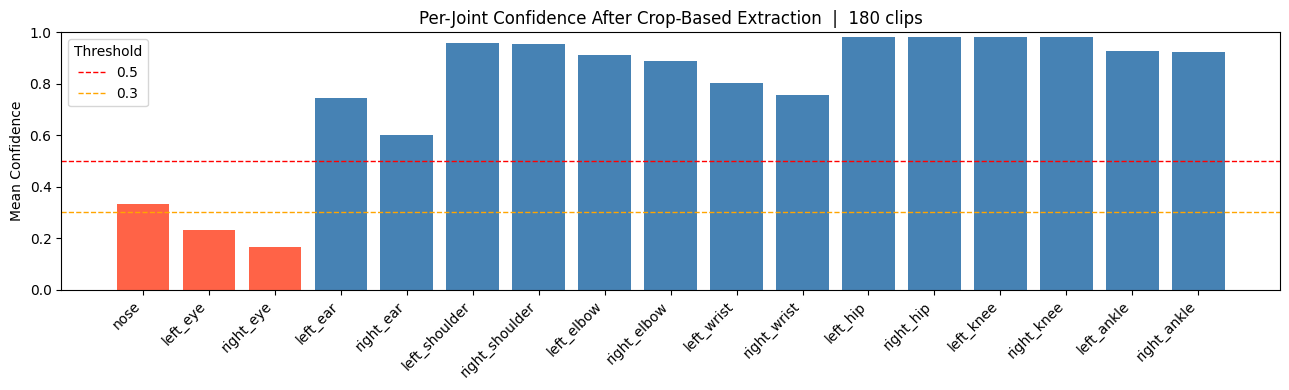

Joints still below 0.5 after cropping:
  nose               0.333
  left_eye           0.231
  right_eye          0.168

Note: ankle and foot joints are commonly low in badminton footage
because the lower body is sometimes cut off. This is expected.


In [13]:
npy_files = list(Path(KEYPOINTS_DIR).rglob('*.npy'))

if npy_files:
    all_conf  = np.stack([np.load(p)[:, :, 2] for p in npy_files])
    mean_conf = all_conf.mean(axis=(0, 1))

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(KEYPOINT_NAMES, mean_conf,
           color=['tomato' if c < 0.5 else 'steelblue' for c in mean_conf])
    ax.axhline(0.5, color='red',    linestyle='--', linewidth=1, label='0.5')
    ax.axhline(0.3, color='orange', linestyle='--', linewidth=1, label='0.3')
    ax.set_ylabel('Mean Confidence')
    ax.set_title(f'Per-Joint Confidence After Crop-Based Extraction  |  {len(npy_files)} clips')
    ax.set_ylim(0, 1)
    ax.legend(title='Threshold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    out = os.path.join(BASE, 'outputs/keypoint_confidence_after_crop.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()

    low_joints = [(KEYPOINT_NAMES[j], round(float(mean_conf[j]), 3))
                  for j in range(17) if mean_conf[j] < 0.5]
    if low_joints:
        print("Joints still below 0.5 after cropping:")
        for name, conf in low_joints:
            print(f"  {name:<18} {conf}")
        print()
        print("Note: ankle and foot joints are commonly low in badminton footage")
        print("because the lower body is sometimes cut off. This is expected.")
    else:
        print("All joints above 0.5 after cropping.")

---
## Section 8 - Summary and Next Steps

In [14]:
npy_count = len(list(Path(KEYPOINTS_DIR).rglob('*.npy')))

print("NOTEBOOK 02 COMPLETE")
print("-" * 45)
print(f"  Clips reprocessed  : {len(sampled_clips)}")
print(f"  .npy files saved   : {npy_count}")
print(f"  Array shape        : ({TARGET_FRAMES}, {NUM_KEYPOINTS}, 3) per clip")
print(f"  Coordinates        : normalised to player crop (0 to 1 range)")
print(f"  Saved to           : {KEYPOINTS_DIR}")
print()
print("What changed from Notebook 01:")
print("  - Keypoints extracted from player crop, not the full 1280x720 frame")
print("  - Bounding box expanded by", BBOX_PADDING, "on each side before cropping")
print("  - x and y coordinates normalised to 0-1 relative to crop size")
print("  - Both far-court and near-court players now in consistent coordinate space")
print()
print("Things to note before the next session:")
print("  - Did wrist confidence improve vs Notebook 01?")
print("  - Are ankle/foot joints consistently low? (expected in court footage)")
print("  - Check the crop preview for a few different classes")
print()
print("Next notebook (03):")
print("  - Build ST-Graph tensors from the normalised keypoint arrays")
print("  - Define the adjacency matrix for the 17-joint COCO skeleton")
print("  - Train an LSTM baseline classifier")
print("  - First confusion matrix and per-class accuracy")

NOTEBOOK 02 COMPLETE
---------------------------------------------
  Clips reprocessed  : 180
  .npy files saved   : 180
  Array shape        : (30, 17, 3) per clip
  Coordinates        : normalised to player crop (0 to 1 range)
  Saved to           : /content/drive/MyDrive/14486346_Honours/data/keypoints

What changed from Notebook 01:
  - Keypoints extracted from player crop, not the full 1280x720 frame
  - Bounding box expanded by 0.15 on each side before cropping
  - x and y coordinates normalised to 0-1 relative to crop size
  - Both far-court and near-court players now in consistent coordinate space

Things to note before the next session:
  - Did wrist confidence improve vs Notebook 01?
  - Are ankle/foot joints consistently low? (expected in court footage)
  - Check the crop preview for a few different classes

Next notebook (03):
  - Build ST-Graph tensors from the normalised keypoint arrays
  - Define the adjacency matrix for the 17-joint COCO skeleton
  - Train an LSTM basel